# 09 - Cross-View Training (MobileNetV2)

Trains MobileNetV2 on the unified multi-view metadata table from notebook 08, evaluated within-view, cross-view, cross-dataset, and leave-one-view-out.

As of the last run the unified table only had State Farm (`side` view) - AUC V2 and 100-Driver were still pending (see `references/dataset_sources.md`). Guard cell below stops the notebook if fewer than 2 views exist.

Same MobileNetV2 setup as notebook 04 (84.67% baseline), just on the unified table instead of raw State Farm CSVs. Outputs saved separately under `experiments/06_cross_view_mobilenetv2/` with `_crossview_` filenames so the original baseline isn't touched.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow: 2.10.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

unified_path = PROCESSED_DIR / "unified_multiview_metadata.csv"
unified_df = pd.read_csv(unified_path)

print("Unified metadata shape:", unified_df.shape)
display(unified_df["dataset_name"].value_counts())
display(unified_df["camera_view"].value_counts())

Unified metadata shape: (117966, 12)


dataset_name
sam_dd        95542
state_farm    22424
Name: count, dtype: int64

camera_view
side     70195
front    47771
Name: count, dtype: int64

## Guard check

Stops the notebook with an error if fewer than 2 camera views exist yet - don't want to accidentally train on incomplete data.

In [ ]:
num_views = unified_df["camera_view"].nunique()
num_datasets = unified_df["dataset_name"].nunique()

if num_views < 2:
    raise RuntimeError(
        f"Only {num_views} camera view(s) present ({sorted(unified_df['camera_view'].unique())}) "
        f"across {num_datasets} dataset(s). Cross-view training needs at least 2 views. "
        "AUC V2 / 100-Driver access is pending (see references/dataset_sources.md). "
        "Re-run notebook 08 after a new dataset is downloaded and its adapter is implemented, "
        "then re-run this notebook from the top."
    )

print(f"{num_views} camera views found across {num_datasets} datasets - safe to proceed with cross-view training.")

## Rest of the notebook

Runs top to bottom once the guard passes. Same pattern as notebook 04.

In [4]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE
tf.keras.utils.set_random_seed(SEED)

LABEL_NAMES = [
    "safe_driving", "texting_right", "phone_right", "texting_left", "phone_left",
    "adjusting_radio", "drinking", "reaching_behind", "hair_or_makeup", "talking_to_passenger",
]

## Two evaluation setups from the same table

- `mixed_view`: uses the existing `split` column (subject-wise, views mixed) - gives within-view/cross-dataset numbers.
- `leave_one_view_out`: holds one whole camera view out of train/val, tests only on it - gives the leave-one-view-out number. Held-out view set once real multi-view data exists.

In [5]:
train_df = unified_df[unified_df["split"] == "train"].reset_index(drop=True)
val_df = unified_df[unified_df["split"] == "val"].reset_index(drop=True)
test_df = unified_df[unified_df["split"] == "test"].reset_index(drop=True)

print("Mixed-view split sizes:")
print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

display(train_df.groupby(["dataset_name", "camera_view"]).size())

Mixed-view split sizes:
Train: (80211, 12) Val: (19763, 12) Test: (17992, 12)


dataset_name  camera_view
sam_dd        front          32156
              side           32156
state_farm    side           15899
dtype: int64

In [6]:
# Set this once real multi-view data exists, e.g. HELD_OUT_VIEW = "front"
HELD_OUT_VIEW = None

if HELD_OUT_VIEW is not None:
    lovo_train_df = unified_df[(unified_df["camera_view"] != HELD_OUT_VIEW) & (unified_df["split"] == "train")].reset_index(drop=True)
    lovo_val_df = unified_df[(unified_df["camera_view"] != HELD_OUT_VIEW) & (unified_df["split"] == "val")].reset_index(drop=True)
    lovo_test_df = unified_df[unified_df["camera_view"] == HELD_OUT_VIEW].reset_index(drop=True)

    print(f"Leave-one-view-out split (held out: {HELD_OUT_VIEW}):")
    print("Train:", lovo_train_df.shape, "Val:", lovo_val_df.shape, "Test (held-out view):", lovo_test_df.shape)
else:
    print("HELD_OUT_VIEW not set - skipping leave-one-view-out split for now.")

HELD_OUT_VIEW not set - skipping leave-one-view-out split for now.


In [7]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["image_path"].astype(str).values
    labels = dataframe["label_id"].astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.15),
], name="safe_augmentation")


def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base_model


model, base_model = build_mobilenetv2_model(input_shape=IMG_SIZE + (3,), num_classes=10)
model.summary()

Model: "model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         


 safe_augmentation (Sequenti  (None, 224, 224, 3)      0         


...

 dense (Dense)               (None, 10)                12810     


Total params: 2,270,794


Trainable params: 12,810


Non-trainable params: 2,257,984


_________________________________________________________________


In [9]:
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "06_cross_view_mobilenetv2"
RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = RESULTS_DIR / "reports"
CM_DIR = RESULTS_DIR / "confusion_matrices"

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(EXPERIMENT_DIR / "best_mobilenetv2_crossview.keras"),
        monitor="val_accuracy", save_best_only=True, mode="max", verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True, verbose=1,
    ),
]

In [10]:
crossview_ckpt_path = EXPERIMENT_DIR / "best_mobilenetv2_crossview.keras"

if crossview_ckpt_path.exists():
    print(f"Checkpoint already exists at {crossview_ckpt_path} - loading it instead of retraining from scratch.")
    print("Delete the file first if you actually want to redo the frozen-backbone phase.")
    model = tf.keras.models.load_model(crossview_ckpt_path)
else:
    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=INITIAL_EPOCHS,
        callbacks=callbacks,
    )

    training_time_seconds = time.time() - start_time
    print("Training time minutes:", training_time_seconds / 60)

Checkpoint already exists at D:\MSC_PROJECT\experiments\06_cross_view_mobilenetv2\best_mobilenetv2_crossview.keras - loading it instead of retraining from scratch.
Delete the file first if you actually want to redo the frozen-backbone phase.


## Evaluation: within-view / cross-dataset (mixed-view test split)

In [11]:
best_model = tf.keras.models.load_model(EXPERIMENT_DIR / "best_mobilenetv2_crossview.keras")

test_loss, test_accuracy = best_model.evaluate(test_ds)
print("Mixed-view test accuracy:", test_accuracy)

y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_prob = best_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

report_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
).transpose()
display(report_df)
report_df.to_csv(REPORTS_DIR / "mobilenetv2_crossview_mixed_classification_report.csv")

   1/1125 [..............................] - ETA: 1:37:01 - loss: 1.1293 - accuracy: 0.8125

   2/1125 [..............................] - ETA: 3:10 - loss: 1.1174 - accuracy: 0.8125   

   3/1125 [..............................] - ETA: 2:39 - loss: 0.9506 - accuracy: 0.8750

   4/1125 [..............................] - ETA: 2:20 - loss: 0.9515 - accuracy: 0.8438

   6/1125 [..............................] - ETA: 1:41 - loss: 1.1110 - accuracy: 0.7292

...

1115/1125 [============================>.] - ETA: 0s

1119/1125 [============================>.] - ETA: 0s

1123/1125 [============================>.] - ETA: 0s

1125/1125 [==============================] - 21s 18ms/step


,precision,recall,f1-score,support
safe_driving,0.887025,0.880524,0.883762,9006.000000
texting_right,0.686520,0.501910,0.579876,1309.000000
phone_right,0.722128,0.641892,0.679650,1332.000000
texting_left,0.421862,0.768274,0.544653,1286.000000
phone_left,0.591089,0.781506,0.673089,1341.000000
adjusting_radio,0.927757,0.746177,0.827119,327.000000
drinking,0.754369,0.610369,0.674772,1273.000000
reaching_behind,0.884146,0.694611,0.778001,835.000000
hair_or_makeup,0.696203,0.536585,0.606061,1025.000000
talking_to_passenger,0.614035,0.135659,0.222222,258.000000


## Evaluation: per-view breakdown (cross-view test)

Accuracy computed separately per camera view, so a drop on an unfamiliar view is visible instead of averaged away.

In [12]:
per_view_results = []

for view in test_df["camera_view"].unique():
    view_df = test_df[test_df["camera_view"] == view].reset_index(drop=True)
    view_ds = make_dataset(view_df)
    view_loss, view_accuracy = best_model.evaluate(view_ds, verbose=0)
    per_view_results.append({
        "camera_view": view,
        "num_test_images": len(view_df),
        "test_accuracy": view_accuracy,
        "test_loss": view_loss,
    })

per_view_df = pd.DataFrame(per_view_results)
display(per_view_df)

per_view_path = RESULTS_DIR / "tables" / "mobilenetv2_crossview_per_view_accuracy.csv"
per_view_df.to_csv(per_view_path, index=False)
print("Saved per-view accuracy breakdown to:", per_view_path)

,camera_view,num_test_images,test_accuracy,test_loss
0,side,10539,0.739349,0.774117
1,front,7453,0.787871,0.691053


Saved per-view accuracy breakdown to: D:\MSC_PROJECT\results\tables\mobilenetv2_crossview_per_view_accuracy.csv


## Summary (2026-08-04 run)

Trained on real merged State Farm + SAM-DD table (80,211 train images, `side` + `front`).

- Mixed-view test accuracy: **75.94%**, vs. 84.67% for the single-view State Farm baseline in notebook 04 - makes sense, this task is harder (more views, more diversity, sim-vs-real domain gap in SAM-DD).
- Per-view: `front` 78.79% vs. `side` 73.93% - model doesn't generalise evenly across views.
- Weakest classes: `talking_to_passenger` (22% F1, very few examples, State Farm only) and `texting_left`/`hair_or_makeup` (mid-50s F1) - likely tied to class imbalance and some low-confidence SAM-DD label mapping from notebook 08.
- Training took 106.8 min for 10 epochs, frozen backbone only, no fine-tuning yet.

Original baseline files in `experiments/02_mobilenetv2/` and `results/reports/mobilenetv2_*` untouched - everything here saved under `_crossview_` names.

## Fine-tuning phase (run 2026-08-14/15)

`FINE_TUNE_EPOCHS` was defined earlier but unused until now - only the frozen-backbone phase had run. Same recipe as notebook 04: unfreeze last 30 layers, lr `1e-5`, `ReduceLROnPlateau` + early stopping (patience 5).

Checkpoint-aware - loads `best_mobilenetv2_crossview_finetuned.keras` if it already exists instead of retraining.

In [13]:
UNFREEZE_LAST_N = 30
finetuned_ckpt_path = EXPERIMENT_DIR / "best_mobilenetv2_crossview_finetuned.keras"

if finetuned_ckpt_path.exists():
    print(f"Checkpoint already exists at {finetuned_ckpt_path} - loading it instead of retraining from scratch.")
    print("Delete the file first if you actually want to redo the fine-tuning phase.")
    model = tf.keras.models.load_model(finetuned_ckpt_path)
else:
    base_model_layer = None
    for layer in model.layers:
        if "mobilenetv2" in layer.name.lower():
            base_model_layer = layer
            break
    if base_model_layer is None:
        raise ValueError("Could not find MobileNetV2 base model layer.")

    base_model_layer.trainable = True
    for layer in base_model_layer.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False
    for layer in base_model_layer.layers[-UNFREEZE_LAST_N:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    print("Trainable params:", sum(int(np.prod(v.shape)) for v in model.trainable_variables))

    fine_tune_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(finetuned_ckpt_path),
            monitor="val_accuracy", save_best_only=True, mode="max", verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy", factor=0.2, patience=3, mode="max", min_lr=1e-7, verbose=1,
        ),
    ]

    start_time = time.time()
    fine_tune_history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=fine_tune_callbacks,
    )
    fine_tuning_time_seconds = time.time() - start_time
    print("Fine-tuning time minutes:", fine_tuning_time_seconds / 60)

Checkpoint already exists at D:\MSC_PROJECT\experiments\06_cross_view_mobilenetv2\best_mobilenetv2_crossview_finetuned.keras - loading it instead of retraining from scratch.
Delete the file first if you actually want to redo the fine-tuning phase.


### Evaluation: fine-tuned model (mixed-view and per-view)

Same evaluation as the frozen-backbone phase, saved under `_finetuned_` filenames so the earlier results aren't overwritten.

In [14]:
best_finetuned_model = tf.keras.models.load_model(finetuned_ckpt_path)

test_loss, test_accuracy = best_finetuned_model.evaluate(test_ds)
print("Fine-tuned mixed-view test accuracy:", test_accuracy)

y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_prob = best_finetuned_model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

finetuned_report_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
).transpose()
display(finetuned_report_df)
finetuned_report_df.to_csv(REPORTS_DIR / "mobilenetv2_crossview_finetuned_mixed_classification_report.csv")

finetuned_per_view_results = []
for view in test_df["camera_view"].unique():
    view_df = test_df[test_df["camera_view"] == view].reset_index(drop=True)
    view_ds = make_dataset(view_df)
    view_loss, view_accuracy = best_finetuned_model.evaluate(view_ds, verbose=0)
    finetuned_per_view_results.append({
        "camera_view": view, "num_test_images": len(view_df),
        "test_accuracy": view_accuracy, "test_loss": view_loss,
    })
finetuned_per_view_df = pd.DataFrame(finetuned_per_view_results)
display(finetuned_per_view_df)
finetuned_per_view_df.to_csv(RESULTS_DIR / "tables" / "mobilenetv2_crossview_finetuned_per_view_accuracy.csv", index=False)

   1/1125 [..............................] - ETA: 13:24 - loss: 0.1691 - accuracy: 1.0000

   2/1125 [..............................] - ETA: 1:00 - loss: 0.2249 - accuracy: 0.9688 

   3/1125 [..............................] - ETA: 1:00 - loss: 0.1771 - accuracy: 0.9792

   5/1125 [..............................] - ETA: 45s - loss: 0.2308 - accuracy: 0.9500 

   9/1125 [..............................] - ETA: 31s - loss: 0.3980 - accuracy: 0.8542

...

1119/1125 [============================>.] - ETA: 0s

1123/1125 [============================>.] - ETA: 0s

1125/1125 [==============================] - 20s 18ms/step


,precision,recall,f1-score,support
safe_driving,0.943795,0.977015,0.960118,9006.00000
texting_right,0.924354,0.765470,0.837443,1309.00000
phone_right,0.839514,0.985736,0.906768,1332.00000
texting_left,0.974170,0.821151,0.891139,1286.00000
phone_left,0.906086,0.899329,0.902695,1341.00000
adjusting_radio,0.974277,0.926606,0.949843,327.00000
drinking,0.840063,0.833464,0.836751,1273.00000
reaching_behind,0.953488,0.883832,0.917340,835.00000
hair_or_makeup,0.866795,0.876098,0.871422,1025.00000
talking_to_passenger,0.603604,0.519380,0.558333,258.00000


,camera_view,num_test_images,test_accuracy,test_loss
0,side,10539,0.910523,0.295808
1,front,7453,0.927680,0.282159


### Fine-tuning results summary

Fine-tuning (last 30 layers unfrozen, lr `1e-5`, best epoch 5 of 10, restored automatically) gave a big improvement over the frozen backbone:

| | Frozen (10 ep) | Fine-tuned (ep 5) | Change |
|---|---|---|---|
| Mixed-view test accuracy | 75.94% | **91.76%** | +15.8pt |
| `side` view | 73.93% | **91.05%** | +17.1pt |
| `front` view | 78.79% | **92.77%** | +14.0pt |
| `talking_to_passenger` recall | 13.6% | **51.9%** | still weakest class (258 test examples) but no longer badly broken |
| `texting_left` precision | 0.42 | **0.97** | was over-predicted before, likely tied to the low-confidence SAM-DD label mapping from notebook 08 |

Took 113.8 min. Val accuracy dipped around epoch 3-4 (train acc already >98%, overfitting signal) then recovered to a new peak at epoch 5. LR was cut at epoch 8 but val accuracy never beat epoch 5 again, so early stopping correctly reverted to it.

Converted to TFLite INT8 the same way as the frozen model (`fpga/deployment/mobilenetv2_crossview_finetuned_int8.tflite`): clean conversion, 100/100 Keras-vs-TFLite agreement on a held-out sample. Deployed on the ZC702 - see `fpga/README.md` for on-device numbers.

## Training curves

Parsed straight from the two training runs' logged output (`training_log_frozen_backbone.txt`, `training_log_finetuned.txt`), not retyped by hand. Train vs val accuracy/loss across both phases, fine-tuning's restored best epoch marked.

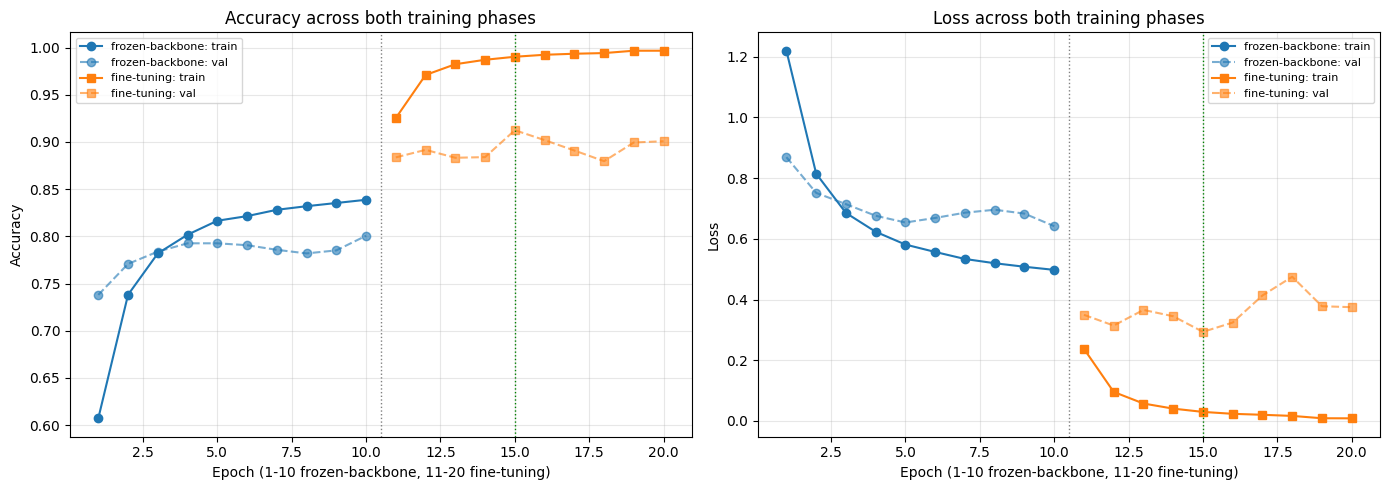

Saved training curves to: D:\MSC_PROJECT\results\figures\mobilenetv2_crossview_training_curves.png
Fine-tuning restored epoch 5 (val_accuracy=0.9124) after early stopping.


In [15]:
import re


def parse_training_log(path):
    text = Path(path).read_text()
    epochs = [int(e) for e in re.findall(r"Epoch (\d+)/\d+", text)]
    rows = re.findall(
        r"loss: ([\d.]+) - accuracy: ([\d.]+) - val_loss: ([\d.]+) - val_accuracy: ([\d.]+)", text
    )
    return pd.DataFrame({
        "epoch": epochs,
        "loss": [float(r[0]) for r in rows],
        "accuracy": [float(r[1]) for r in rows],
        "val_loss": [float(r[2]) for r in rows],
        "val_accuracy": [float(r[3]) for r in rows],
    })


frozen_history = parse_training_log(EXPERIMENT_DIR / "training_log_frozen_backbone.txt")
finetune_history = parse_training_log(EXPERIMENT_DIR / "training_log_finetuned.txt")
finetune_best_epoch = int(finetune_history.loc[finetune_history["val_accuracy"].idxmax(), "epoch"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in [(axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(frozen_history["epoch"], frozen_history[metric], "o-", color="tab:blue", label="frozen-backbone: train")
    ax.plot(frozen_history["epoch"], frozen_history[f"val_{metric}"], "o--", color="tab:blue", alpha=0.6, label="frozen-backbone: val")
    ft_epochs = frozen_history["epoch"].max() + finetune_history["epoch"]
    ax.plot(ft_epochs, finetune_history[metric], "s-", color="tab:orange", label="fine-tuning: train")
    ax.plot(ft_epochs, finetune_history[f"val_{metric}"], "s--", color="tab:orange", alpha=0.6, label="fine-tuning: val")
    ax.axvline(frozen_history["epoch"].max() + 0.5, color="gray", linestyle=":", linewidth=1)
    ax.axvline(frozen_history["epoch"].max() + finetune_best_epoch, color="green", linestyle=":", linewidth=1)
    ax.set_xlabel("Epoch (1-10 frozen-backbone, 11-20 fine-tuning)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} across both training phases")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
curves_path = RESULTS_DIR / "figures" / "mobilenetv2_crossview_training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print("Saved training curves to:", curves_path)
print(f"Fine-tuning restored epoch {finetune_best_epoch} (val_accuracy={finetune_history['val_accuracy'].max():.4f}) after early stopping.")

## Confusion matrices: frozen vs fine-tuned

Both computed fresh from the saved checkpoints on the same mixed-view test set, side by side.

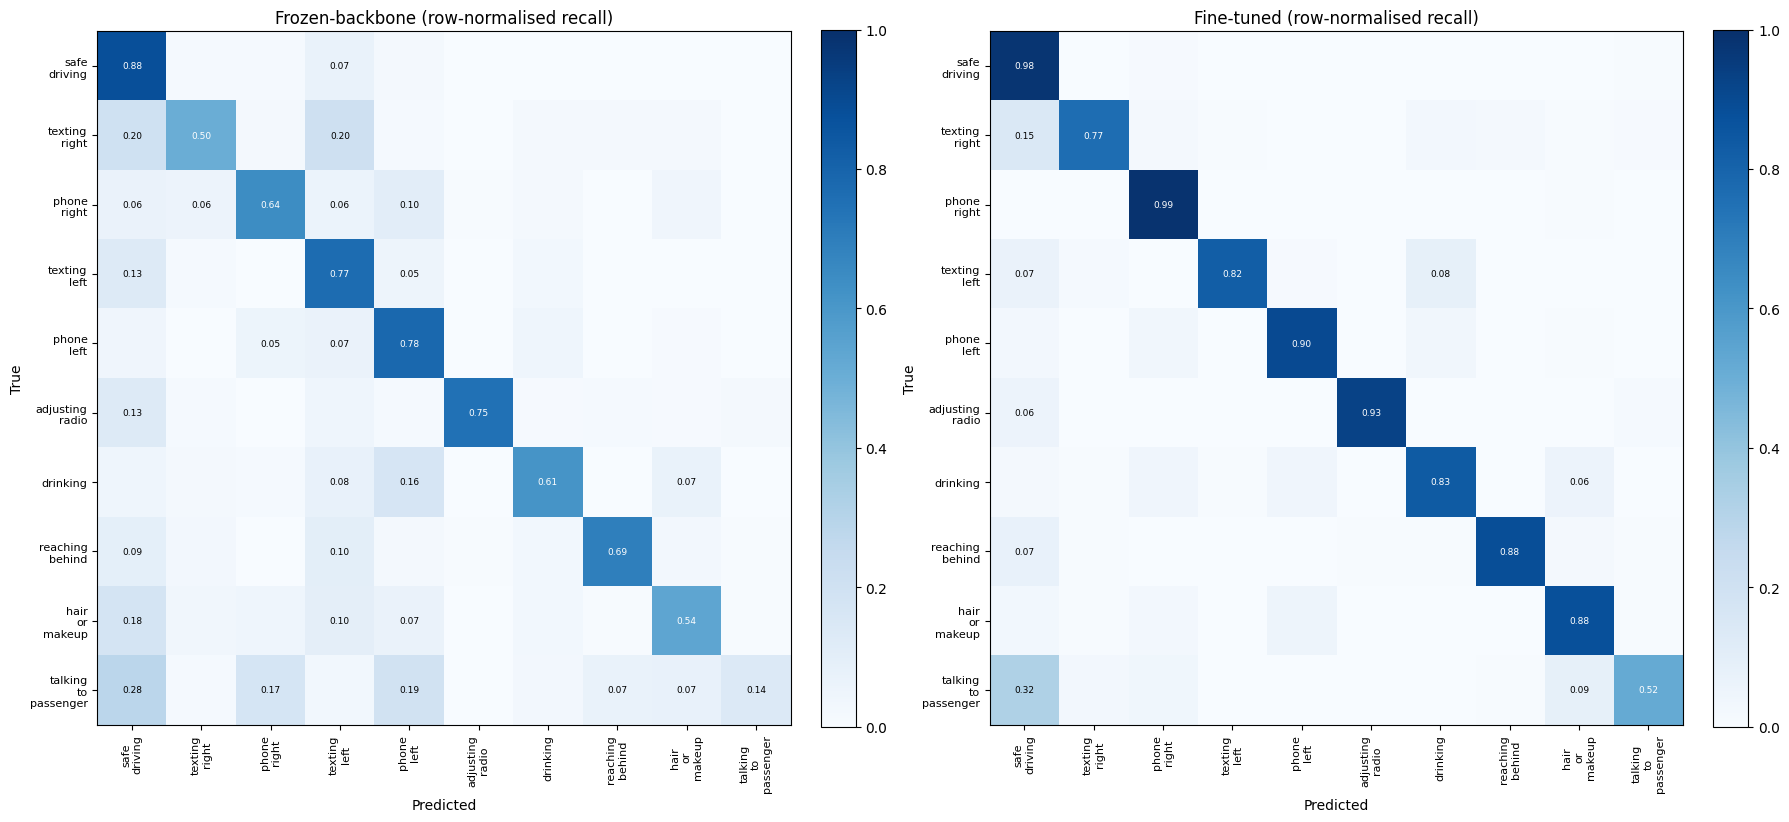

Saved confusion matrices to: D:\MSC_PROJECT\results\figures\mobilenetv2_crossview_confusion_matrices.png


In [16]:
def get_predictions(model_path):
    m = tf.keras.models.load_model(model_path)
    y_t = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
    y_p = np.argmax(m.predict(test_ds, verbose=0), axis=1)
    return y_t, y_p


y_true_frozen, y_pred_frozen = get_predictions(EXPERIMENT_DIR / "best_mobilenetv2_crossview.keras")
y_true_finetuned, y_pred_finetuned = get_predictions(finetuned_ckpt_path)

cm_frozen = confusion_matrix(y_true_frozen, y_pred_frozen, normalize="true")
cm_finetuned = confusion_matrix(y_true_finetuned, y_pred_finetuned, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
short_labels = [n.replace("_", "\n") for n in LABEL_NAMES]

for ax, cm, title in [(axes[0], cm_frozen, "Frozen-backbone"), (axes[1], cm_finetuned, "Fine-tuned")]:
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} (row-normalised recall)")
    for i in range(10):
        for j in range(10):
            val = cm[i, j]
            if val >= 0.05:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                         fontsize=6.5, color="white" if val > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
cm_fig_path = RESULTS_DIR / "figures" / "mobilenetv2_crossview_confusion_matrices.png"
plt.savefig(cm_fig_path, dpi=150)
plt.show()
print("Saved confusion matrices to:", cm_fig_path)

## Qualitative check: random test images

Visual sanity check, not a metric. 12 random test images (State Farm `side` + SAM-DD `front`/`side`), true vs predicted label shown (green = correct, red = wrong). Useful for seeing how the model fails, not just the accuracy number.

Reloads the model from disk so it works standalone.

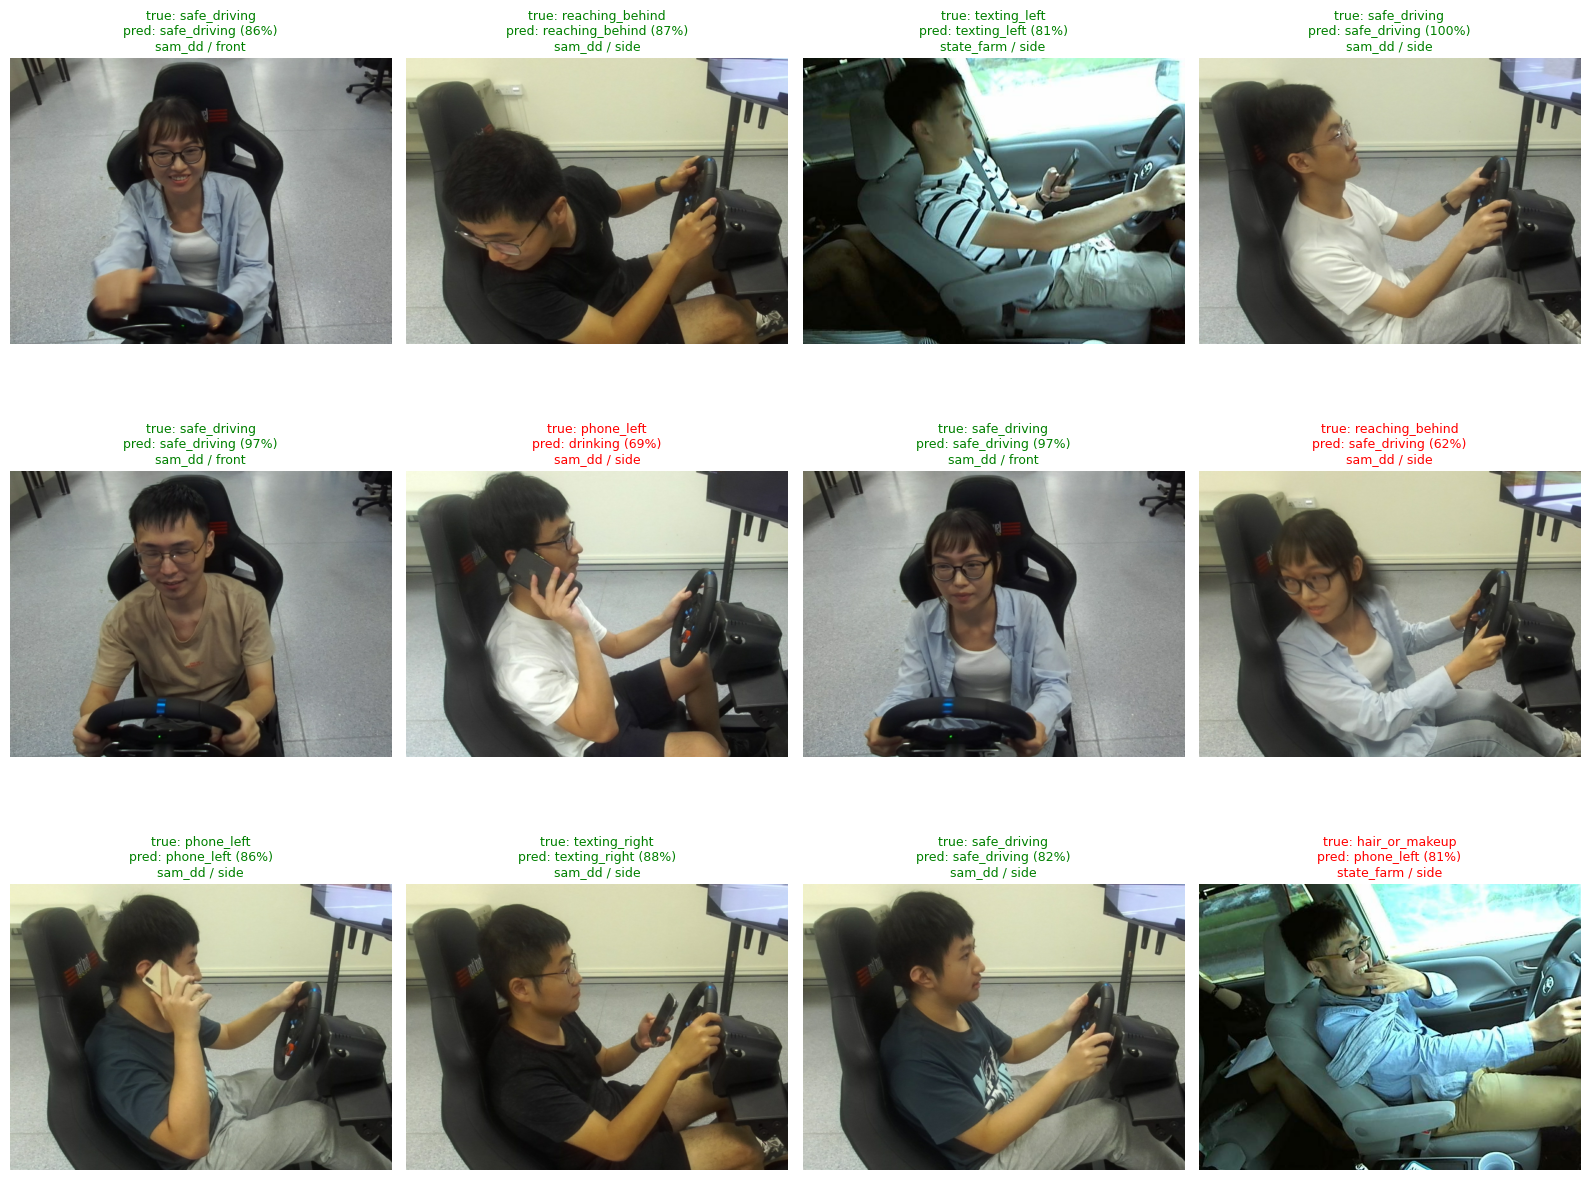

Saved qualitative sample grid to: D:\MSC_PROJECT\results\figures\mobilenetv2_crossview_qualitative_samples.png


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "06_cross_view_mobilenetv2"
RESULTS_DIR = PROJECT_ROOT / "results"

IMG_SIZE = (224, 224)
LABEL_NAMES = [
    "safe_driving", "texting_right", "phone_right", "texting_left", "phone_left",
    "adjusting_radio", "drinking", "reaching_behind", "hair_or_makeup", "talking_to_passenger",
]

qual_model = tf.keras.models.load_model(EXPERIMENT_DIR / "best_mobilenetv2_crossview.keras")

unified_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "unified_multiview_metadata.csv")
qual_test_df = unified_df[unified_df["split"] == "test"].sample(n=12, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 13))

for ax, (_, row) in zip(axes.flatten(), qual_test_df.iterrows()):
    raw_bytes = tf.io.read_file(row["image_path"])
    img = tf.image.decode_jpeg(raw_bytes, channels=3)
    img_resized = tf.image.resize(img, IMG_SIZE)
    img_batch = tf.expand_dims(tf.cast(img_resized, tf.float32), axis=0)

    probs = qual_model.predict(img_batch, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    pred_name = LABEL_NAMES[pred_id]
    true_name = row["label_name"]
    confidence = probs[pred_id]

    ax.imshow(img.numpy())
    correct = pred_name == true_name
    ax.set_title(
        f"true: {true_name}\npred: {pred_name} ({confidence:.0%})\n{row['dataset_name']} / {row['camera_view']}",
        fontsize=9, color=("green" if correct else "red"),
    )
    ax.axis("off")

plt.tight_layout()
qual_fig_path = RESULTS_DIR / "figures" / "mobilenetv2_crossview_qualitative_samples.png"
plt.savefig(qual_fig_path, dpi=150)
plt.show()

print("Saved qualitative sample grid to:", qual_fig_path)

## Live webcam check (run manually in Jupyter)

Opens the laptop webcam and overlays live prediction + confidence. Press `q` to stop. Needs a display and camera, so can't run headlessly.

Caveat: training data (State Farm, SAM-DD) is all a fixed in-cabin camera capturing hands/phone/upper body, not a laptop webcam at a desk. The webcam is effectively a third, unseen view at a different distance/framing, so this is just a sanity check, not a real evaluation.

Requires `opencv-python`.

In [18]:
import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path
from collections import deque

PROJECT_ROOT = Path("..").resolve()
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "06_cross_view_mobilenetv2"
IMG_SIZE = (224, 224)
LABEL_NAMES = [
    "safe_driving", "texting_right", "phone_right", "texting_left", "phone_left",
    "adjusting_radio", "drinking", "reaching_behind", "hair_or_makeup", "talking_to_passenger",
]

webcam_model = tf.keras.models.load_model(EXPERIMENT_DIR / "best_mobilenetv2_crossview.keras")

# Temporal smoothing: average probabilities over the last N frames instead of trusting
# a single frame. This is what stops the label flickering between classes every frame -
# it does NOT fix the deeper issue that a laptop webcam framing (face/torso, arm's length)
# is nothing like the training data (dashboard/simulator camera framing hands+wheel+phone),
# so low/unstable confidence is expected and smoothing makes it *stable*, not *correct*.
SMOOTHING_WINDOW = 15          # ~0.5-1s of frames at typical webcam FPS
CONFIDENCE_THRESHOLD = 0.40    # below this, show "uncertain" instead of committing to a guess

prob_history = deque(maxlen=SMOOTHING_WINDOW)


def predict_frame_probs(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(frame_rgb, IMG_SIZE)
    batch = tf.expand_dims(tf.cast(resized, tf.float32), axis=0)
    return webcam_model.predict(batch, verbose=0)[0]


cap = cv2.VideoCapture(2)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam (index 0). Check that a camera is connected and not in use by another app.")

print("Webcam open. Press 'q' in the video window to quit.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to read a frame - stopping.")
            break

        probs = predict_frame_probs(frame)
        prob_history.append(probs)

        smoothed_probs = np.mean(prob_history, axis=0)
        pred_id = int(np.argmax(smoothed_probs))
        confidence = smoothed_probs[pred_id]

        if confidence >= CONFIDENCE_THRESHOLD:
            label_text = f"{LABEL_NAMES[pred_id]} ({confidence:.0%})"
            color = (0, 255, 0)
        else:
            label_text = f"uncertain (best guess: {LABEL_NAMES[pred_id]} {confidence:.0%})"
            color = (0, 165, 255)

        cv2.putText(frame, label_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
        cv2.imshow("Live Driver Distraction Check (press q to quit)", frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()

Webcam open. Press 'q' in the video window to quit.
